In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("titanic.csv")

In [3]:
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)

In [4]:
x = df[["Pclass", "Age", "Fare"]]
y = df["Survived"]

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [7]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(x_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [8]:
y_pred = model.predict(x_test_scaled)

In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7206703910614525


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[87 18]
 [32 42]]


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.83      0.78       105
           1       0.70      0.57      0.63        74

    accuracy                           0.72       179
   macro avg       0.72      0.70      0.70       179
weighted avg       0.72      0.72      0.71       179



In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(x_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.7462033462033462


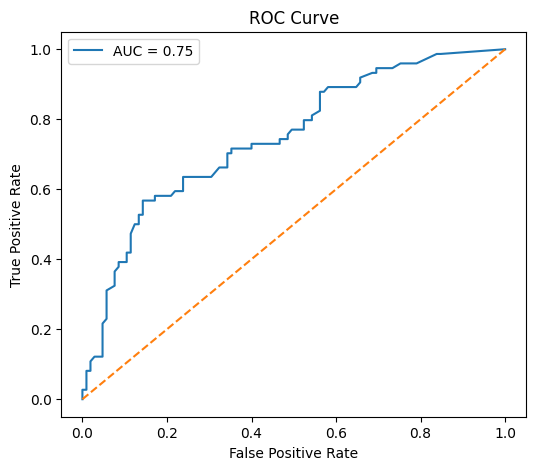

In [13]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.65034965 0.64335664 0.71830986 0.67605634 0.66901408]
Average Accuracy: 0.6714173150792868


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, 7]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(x_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': 3, 'n_estimators': 100}
Best Cross Validation Score: 0.7190288584654783


In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [3, 5, 7, 9, None]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    random_state=42
)

random_search.fit(x_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

Best Parameters: {'n_estimators': 100, 'max_depth': 3}
Best Cross Validation Score: 0.7190288584654783
